In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Konfigurasi kredensial PostgreSQL
DB_USER = "postgres"
DB_PASS = "********"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "olist_ecommerce_dataset"

connection_uri = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_uri)

print("Koneksi ke database olist_ecommerce_dataset berhasil terhubung!")

Koneksi ke database olist_ecommerce_dataset berhasil terhubung!


In [2]:
query_orders = """
SELECT 
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp::timestamp AS order_purchase_timestamp,
    SUM(oi.price) AS total_order_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id, o.order_id, o.order_purchase_timestamp;
"""

df_orders = pd.read_sql(query_orders, engine)
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

print(f"Total baris transaksi berhasil ditarik: {len(df_orders):,}")
df_orders.head()

Total baris transaksi berhasil ditarik: 96,478


,customer_unique_id,order_id,order_purchase_timestamp,total_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,18.90
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,25.99
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,180.00


In [3]:
# Tanggal acuan: 1 hari setelah pesanan terakhir di dataset
reference_date = df_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Agregasi RFM
rfm = df_orders.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_order_value', 'sum')
).reset_index()

# Scoring (Kuartil untuk R & M, Binned rules untuk F)
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm['f_score'] = rfm['frequency'].apply(lambda x: 3 if x >= 3 else (2 if x == 2 else 1))

# Pemetaan Segmen Bisnis
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 3 and f >= 2 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 1:
        return 'Active / Potential'
    elif r == 2 and f >= 2:
        return 'Need Attention'
    elif r <= 2 and m >= 3:
        return 'At Risk High-Value'
    else:
        return 'Hibernating / Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Ringkasan per segmen
segment_summary = rfm.groupby('segment').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()

segment_summary['pct_customers'] = (segment_summary['total_customers'] / len(rfm)) * 100
segment_summary.sort_values('total_revenue', ascending=False)

,segment,total_customers,avg_recency_days,avg_monetary,total_revenue,pct_customers
0,Active / Potential,45531,112.117458,137.754601,6272104.75,48.770325
1,At Risk High-Value,22439,366.664290,234.915144,5271260.92,24.035433
3,Hibernating / Lost,23399,365.174281,47.288929,1106513.66,25.063733
2,Champions,1316,113.329027,299.874233,394634.49,1.409627
4,Need Attention,673,278.624071,262.978143,176984.29,0.720881


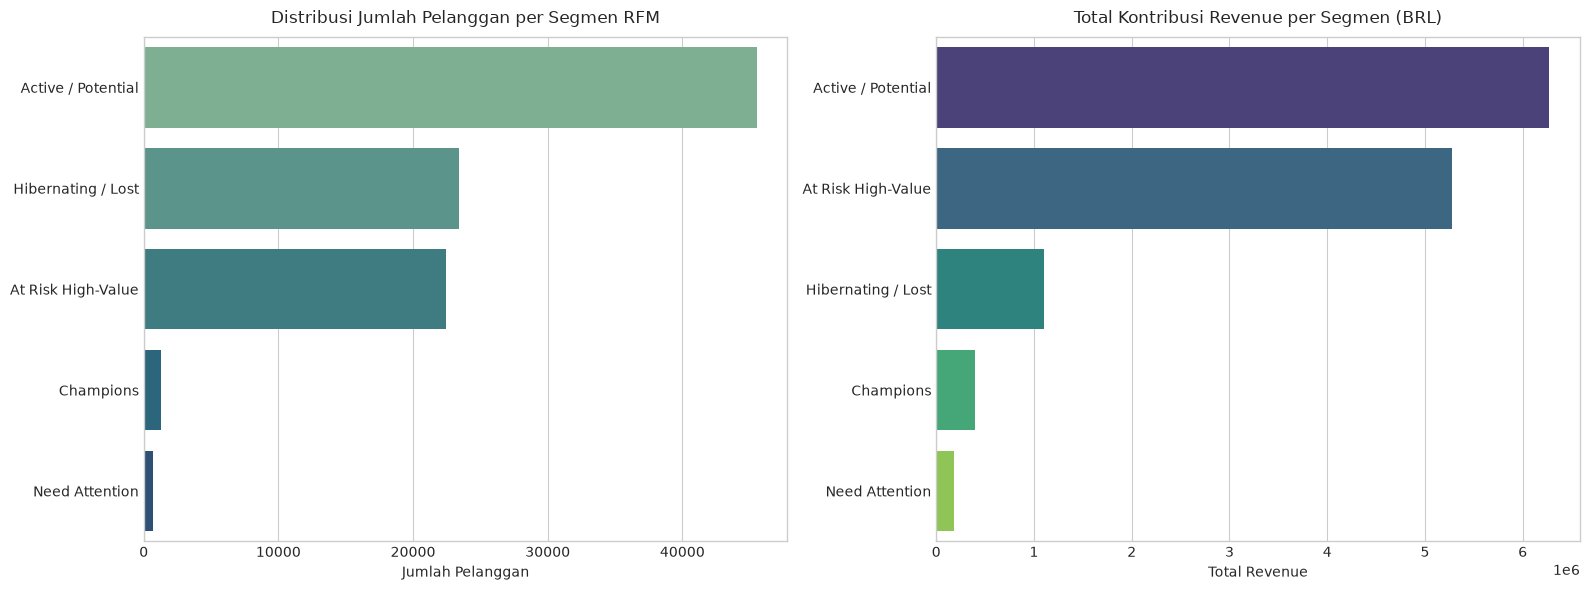

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Jumlah Pelanggan per Segmen
sns.barplot(
    data=segment_summary.sort_values('total_customers', ascending=False),
    x='total_customers',
    y='segment',
    hue='segment',
    palette='crest',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Distribusi Jumlah Pelanggan per Segmen RFM', fontsize=12, pad=10)
axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].set_ylabel('')

# Plot 2: Total Revenue per Segmen
sns.barplot(
    data=segment_summary.sort_values('total_revenue', ascending=False),
    x='total_revenue',
    y='segment',
    hue='segment',
    palette='viridis',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Total Kontribusi Revenue per Segmen (BRL)', fontsize=12, pad=10)
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

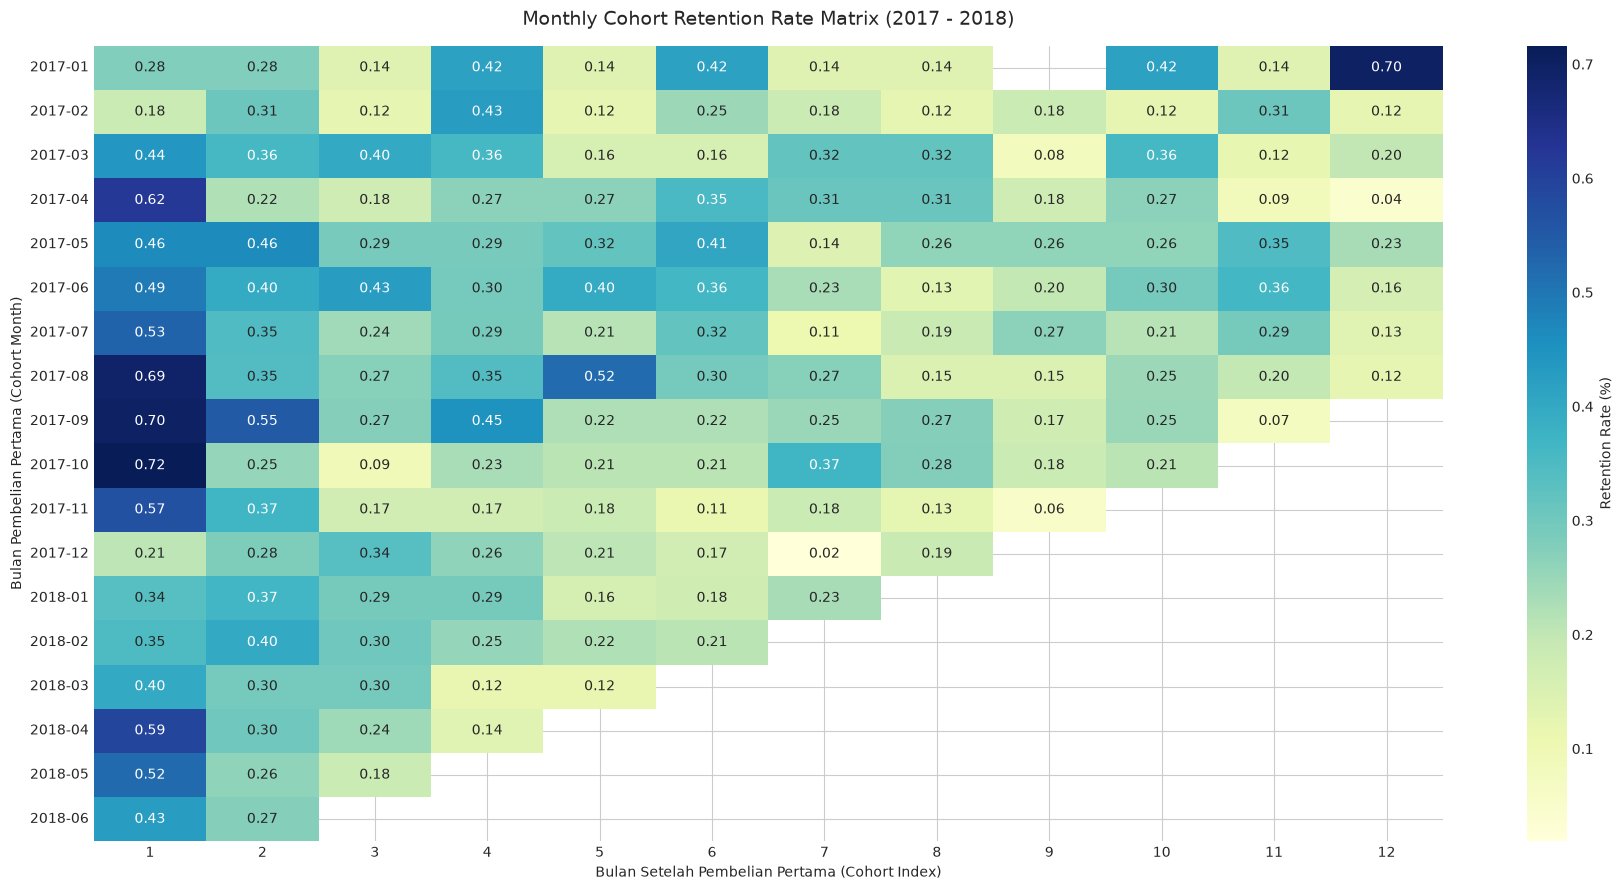

In [6]:
# 1. Konversi periode bulan transaksi
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

# 2. Tentukan bulan pertama belanja (Cohort Month) per customer unik
df_orders['cohort_month'] = df_orders.groupby('customer_unique_id')['order_month'].transform('min')

# 3. Hitung selisih bulan (Cohort Index)
df_orders['cohort_index'] = (
    (df_orders['order_month'].dt.year - df_orders['cohort_month'].dt.year) * 12 +
    (df_orders['order_month'].dt.month - df_orders['cohort_month'].dt.month)
)

# 4. Agregasi jumlah customer per cohort
cohort_data = df_orders.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

# 5. Hitung persentase retensi terhadap ukuran awal cohort (Bulan 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# 6. Visualisasi Heatmap (Filter dari 2017 agar pola terlihat jelas)
plt.figure(figsize=(18, 9))
sns.heatmap(
    retention_matrix.loc['2017-01':'2018-06', 1:12],
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('Monthly Cohort Retention Rate Matrix (2017 - 2018)', fontsize=14, pad=15)
plt.xlabel('Bulan Setelah Pembelian Pertama (Cohort Index)')
plt.ylabel('Bulan Pembelian Pertama (Cohort Month)')
plt.tight_layout()
plt.show()

findfont: Failed to find font weight heavy, now using 700.


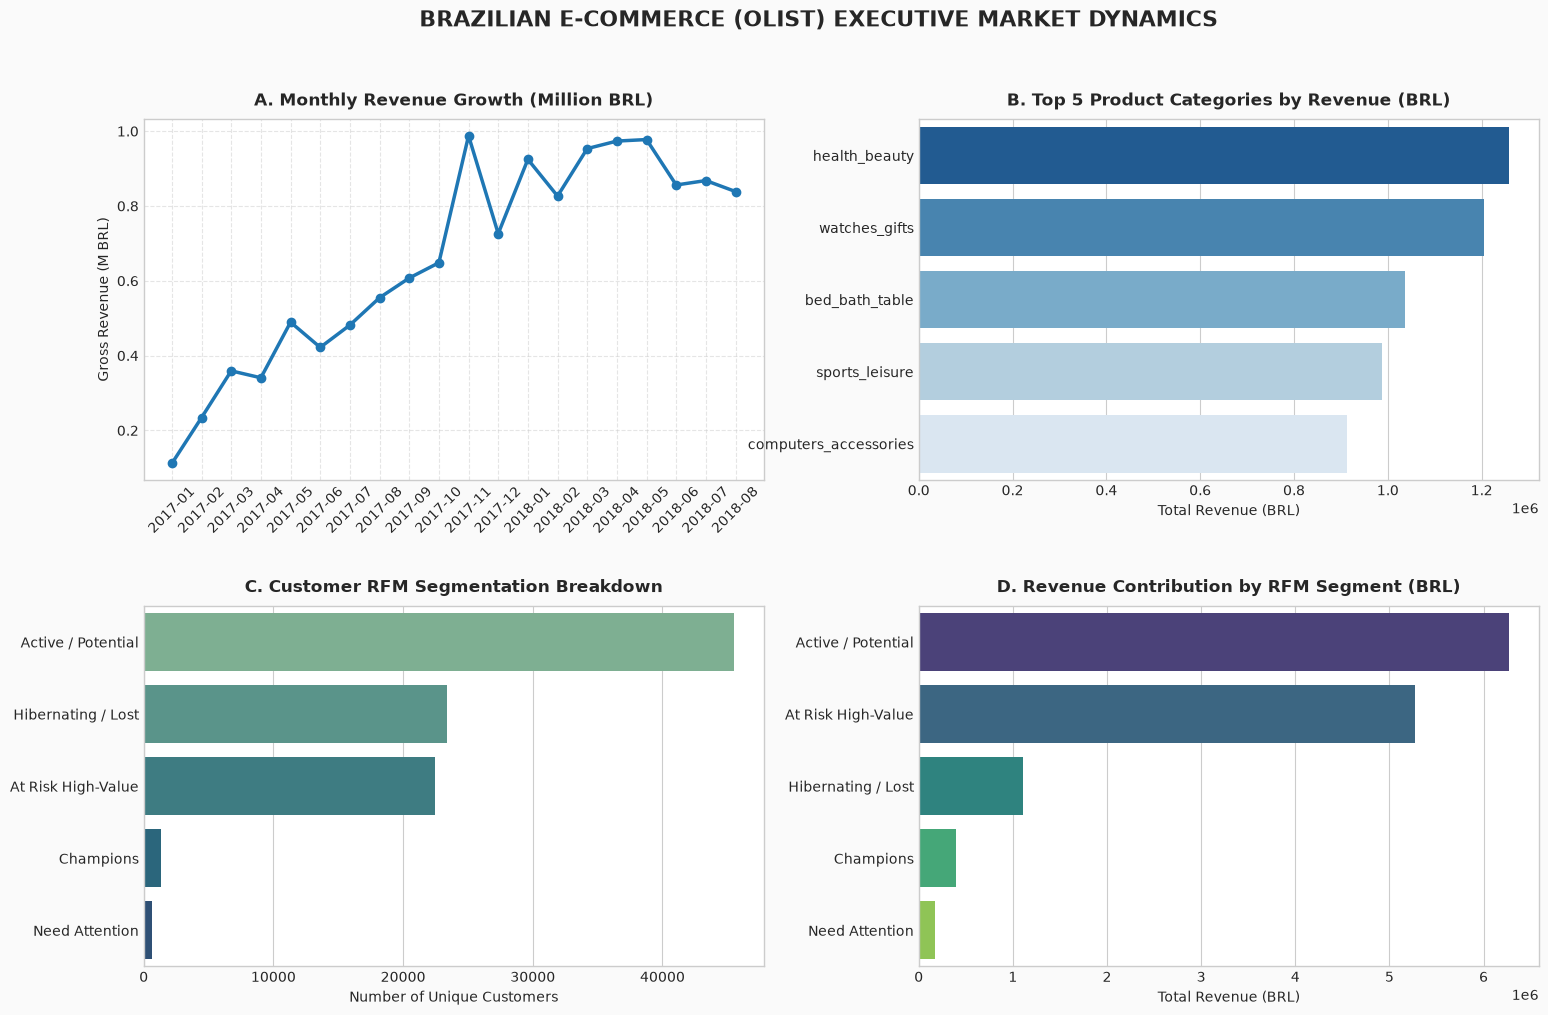

Dashboard visual tersimpan sebagai 'olist_executive_dashboard.png'


In [7]:
# 1. Persiapan Data untuk Visual
# Tren Bulanan
monthly_sales = df_orders.set_index('order_purchase_timestamp').resample('ME')['total_order_value'].sum().reset_index()
monthly_sales = monthly_sales[(monthly_sales['order_purchase_timestamp'] >= '2017-01-01') & (monthly_sales['order_purchase_timestamp'] <= '2018-08-31')]

# Top 5 Kategori (dari SQL view/query)
query_top_cat = """
SELECT 
    COALESCE(pct.product_category_name_english, p.product_category_name, 'Unknown') AS category,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN product_category_translation pct ON p.product_category_name = pct.product_category_name
GROUP BY 1
ORDER BY total_revenue DESC
LIMIT 5;
"""
df_top_cat = pd.read_sql(query_top_cat, engine)

# Canvas Setup
fig, axs = plt.subplots(2, 2, figsize=(18, 11), facecolor='#FAFAFA')
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Panel 1: Monthly Gross Revenue Trend
axs[0, 0].plot(monthly_sales['order_purchase_timestamp'].dt.strftime('%Y-%m'), monthly_sales['total_order_value'] / 1e6, marker='o', color='#1f77b4', linewidth=2.5)
axs[0, 0].set_title('A. Monthly Revenue Growth (Million BRL)', fontsize=12, fontweight='bold', pad=10)
axs[0, 0].set_ylabel('Gross Revenue (M BRL)')
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Panel 2: Top 5 Product Categories by Revenue
sns.barplot(data=df_top_cat, x='total_revenue', y='category', hue='category', palette='Blues_r', legend=False, ax=axs[0, 1])
axs[0, 1].set_title('B. Top 5 Product Categories by Revenue (BRL)', fontsize=12, fontweight='bold', pad=10)
axs[0, 1].set_xlabel('Total Revenue (BRL)')
axs[0, 1].set_ylabel('')

# Panel 3: RFM Customer Distribution
sns.barplot(data=segment_summary.sort_values('total_customers', ascending=False), x='total_customers', y='segment', hue='segment', palette='crest', legend=False, ax=axs[1, 0])
axs[1, 0].set_title('C. Customer RFM Segmentation Breakdown', fontsize=12, fontweight='bold', pad=10)
axs[1, 0].set_xlabel('Number of Unique Customers')
axs[1, 0].set_ylabel('')

# Panel 4: Monetary Contribution by Segment
sns.barplot(data=segment_summary.sort_values('total_revenue', ascending=False), x='total_revenue', y='segment', hue='segment', palette='viridis', legend=False, ax=axs[1, 1])
axs[1, 1].set_title('D. Revenue Contribution by RFM Segment (BRL)', fontsize=12, fontweight='bold', pad=10)
axs[1, 1].set_xlabel('Total Revenue (BRL)')
axs[1, 1].set_ylabel('')

# Main Dashboard Title
fig.suptitle('BRAZILIAN E-COMMERCE (OLIST) EXECUTIVE MARKET DYNAMICS', fontsize=16, fontweight='heavy', y=0.98)

# Simpan sebagai aset gambar
plt.savefig('olist_executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Dashboard visual tersimpan sebagai 'olist_executive_dashboard.png'")